### Download and extract MovieLens 100K dataset

This dataset will be downloaded and extracted into the `data` folder located one level above the current notebook directory.

In [19]:
import requests
import zipfile
import os

url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
output_path = "../ml-100k.zip"   # go up one level

# Download
r = requests.get(url, stream=True)
with open(output_path, "wb") as f:
    for chunk in r.iter_content(chunk_size=8192):
        f.write(chunk)

# Extract into parent directory
with zipfile.ZipFile(output_path, "r") as zip_ref:
    zip_ref.extractall("../data")

os.remove(output_path)

print("Download complete")
print(r"Extracted to MovieLens-Recommender\data")

Download complete
Extracted to MovieLens-Recommender\data


### Load and prepare the MovieLens 100K ratings data

This cell reads the extracted `u.data` file from the MovieLens dataset and parses it into user IDs, item IDs, and ratings. The data is then combined into a structured NumPy array for further processing.

In [28]:
import numpy as np

# Load data from file
with open('../data/ml-100k/u.data', 'r') as file:
    lines = file.readlines()

# Parse users, items, and ratings
users = []
items = []
ratings = []
for line in lines:
    user_id, item_id, rating, _ = line.strip().split('\t')
    users.append(int(user_id))
    items.append(int(item_id))
    ratings.append(int(rating))

# Combine into a NumPy array
data = np.column_stack((users, items, ratings))


### Visualise rating distribution

This cell computes the frequency of each rating value in the dataset and plots the distribution as a bar chart to understand how ratings are spread.

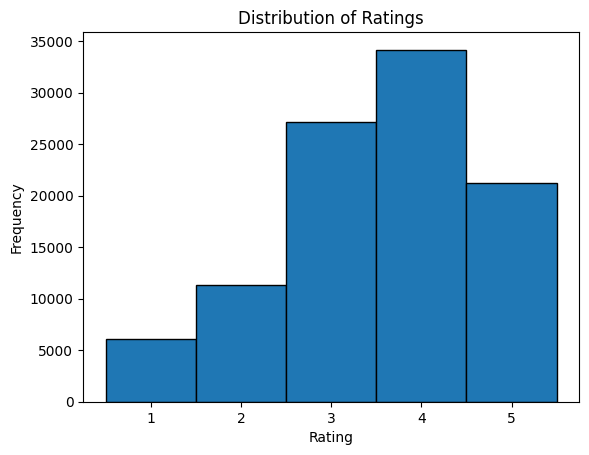

In [29]:
from collections import Counter
import matplotlib.pyplot as plt


# Count frequency of each rating
rating_counts = Counter(ratings)
x = sorted(rating_counts.keys())
y = [rating_counts[r] for r in x]

# Plot rating distribution
plt.bar(x, y, width=1.0, edgecolor='black')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings')
plt.show()

### Train-test split and sparse matrix construction

This cell splits the dataset into training and testing sets on a per-user basis, then constructs sparse user–item and item–user matrices for efficient storage and computation.

In [30]:
from scipy.sparse import lil_matrix
from sklearn.model_selection import train_test_split

# Number of users and items
n_users = np.max(data[:, 0])
n_items = np.max(data[:, 1])

# Initialize sparse matrices
data_by_user_train = lil_matrix((n_users, n_items))
data_by_user_test = lil_matrix((n_users, n_items))
data_by_movie_train = lil_matrix((n_items, n_users))
data_by_movie_test = lil_matrix((n_items, n_users))

# Initialize ratings lists
user_ratings = [[] for _ in range(n_users + 1)]
item_ratings = [[] for _ in range(n_items + 1)]

# Populate user and item ratings
for u, i, r in data:
    user_ratings[int(u)].append((int(i), float(r)))
    item_ratings[int(i)].append((int(u), float(r)))

# Split into train and test
train_data = []
test_data = []

for u in range(1, n_users + 1):
    ratings = user_ratings[u]
    if len(ratings) == 0:
        continue
    elif len(ratings) == 1:
        train_data.append((u, ratings[0][0], ratings[0][1]))
        continue

    train_split, test_split = train_test_split(
        ratings, test_size=0.2, random_state=99
    )

    for i, r in train_split:
        train_data.append((u, i, r))
    for i, r in test_split:
        test_data.append((u, i, r))

train_data = np.array(train_data)
test_data = np.array(test_data)

# Re-initialize user and item ratings for training
user_ratings = [[] for _ in range(n_users + 1)]
item_ratings = [[] for _ in range(n_items + 1)]

# Fill training matrices and lists
for u, i, r in train_data:
    data_by_user_train[int(u) - 1, int(i) - 1] = r
    user_ratings[int(u)].append((int(i), float(r)))
    item_ratings[int(i)].append((int(u), float(r)))

# Fill test matrices
for u, i, r in test_data:
    data_by_user_test[int(u) - 1, int(i) - 1] = r

# Transpose to get movie-by-user matrices
data_by_movie_train = data_by_user_train.transpose().tocsr()
data_by_movie_test = data_by_user_test.transpose().tocsr()

# Mean rating in training data
mu_train = np.mean(train_data[:, 2])

### Baseline model

This cell evaluates a simple baseline model that predicts the global mean rating for all user–item pairs in the test set. The RMSE is computed to serve as a reference point for comparing more advanced recommendation models.

In [40]:
# Convert test data to COO format if not already
test_data = data_by_user_test.tocoo()

# Trivial RMSE: predict global mean for all test entries
trivial_sq_err = 0

for user, item, r in zip(test_data.row, test_data.col, test_data.data):
    pred = mu_train  # global mean
    trivial_sq_err += (r - pred)**2

trivial_rmse = np.sqrt(trivial_sq_err / len(test_data.data))
print(f"Trivial RMSE (predicting global mean) = {trivial_rmse:.4f}")


Trivial RMSE (predicting global mean) = 1.1267


### Alternating least squares (bias-only collaborative filtering)

This cell implements an alternating least squares procedure to learn user and item bias terms under a simple matrix factorisation model with no latent embeddings.

The update equations are:

$$
b_m^{(u)} = \frac{\lambda \sum_{n \in \Omega(m)} \left(r_{mn} - b_n^{(i)}\right)}{\lambda |\Omega(m)| + \gamma}
$$

$$
b_n^{(i)} = \frac{\lambda \sum_{m \in \Omega(n)} \left(r_{mn} - b_m^{(u)}\right)}{\lambda |\Omega(n)| + \gamma}
$$
with $\lambda, \gamma$ as hyperparameters.

A full derivation of this optimisation procedure, together with extensions to latent embeddings and feature-based models, is provided in the file `derivations.md`.

In each iteration, the algorithm alternates between updating user and item biases, evaluates the regularised objective (negative log-likelihood), and tracks both training and test RMSE to monitor convergence and performance relative to the baseline model.

In [41]:
# Hyperparameters
lam = 0.05
gamma = 0.05
max_iter = 20

# Initialize biases
user_bias = np.zeros(n_users)
item_bias = np.zeros(n_items)

# History tracking
nll_history = []
train_rmse_history = []
test_rmse_history = []


for iteration in range(max_iter):
    # Update user biases
    for user in range(1, n_users + 1):
        rated = user_ratings[user]
        bias_sum = 0
        n_rated = 0
        for item, r in rated:
            bias_sum += r - item_bias[item - 1] - mu_train
            n_rated += 1
        user_bias[user - 1] = lam * bias_sum / (lam * n_rated + gamma)

    # Update item biases
    for item in range(1, n_items + 1):
        rated = item_ratings[item]
        bias_sum = 0
        n_rated = 0
        for user, r in rated:
            bias_sum += r - user_bias[user - 1] - mu_train
            n_rated += 1
        item_bias[item - 1] = lam * bias_sum / (lam * n_rated + gamma)

    # Compute negative log-likelihood 
    squared_error = 0
    for user in range(1, n_users + 1):
        for item, r in user_ratings[user]:
            pred = user_bias[user - 1] + item_bias[item - 1] + mu_train
            squared_error += (r - pred) ** 2

    reg_user = np.sum(user_bias ** 2)
    reg_item = np.sum(item_bias ** 2)
    nll = (lam / 2) * squared_error + (gamma / 2) * (reg_user + reg_item)
    nll_history.append(nll)

    # Compute training RMSE
    train_sq_err = 0
    n_train = 0
    for user in range(1, n_users + 1):
        for item, r in user_ratings[user]:
            pred = user_bias[user - 1] + item_bias[item - 1] + mu_train
            train_sq_err += (r - pred) ** 2
            n_train += 1
    train_rmse = np.sqrt(train_sq_err / n_train)
    train_rmse_history.append(train_rmse)

    # Compute test RMSE
    test_sq_err = 0
    n_test = 0
    test_data = data_by_user_test.tocoo()
    for user, item, r in zip(test_data.row, test_data.col, test_data.data):
        pred = user_bias[user] + item_bias[item] + mu_train
        test_sq_err += (r - pred) ** 2
        n_test += 1
    test_rmse = np.sqrt(test_sq_err / n_test)
    test_rmse_history.append(test_rmse)

    # Print progress every 2 iterations
    if (iteration + 1) % 2 == 0:
        print(
            f"Iteration {iteration + 1}, "
            f"NLL = {nll:.4f}, "
            f"Train RMSE = {train_rmse:.4f}, "
            f"Test RMSE = {test_rmse:.4f}"
        )

Iteration 2, NLL = 1682.2395, Train RMSE = 0.9142, Test RMSE = 0.9340
Iteration 4, NLL = 1678.8834, Train RMSE = 0.9131, Test RMSE = 0.9328
Iteration 6, NLL = 1678.6299, Train RMSE = 0.9131, Test RMSE = 0.9327
Iteration 8, NLL = 1678.4289, Train RMSE = 0.9130, Test RMSE = 0.9327
Iteration 10, NLL = 1678.2512, Train RMSE = 0.9130, Test RMSE = 0.9326
Iteration 12, NLL = 1678.0936, Train RMSE = 0.9130, Test RMSE = 0.9326
Iteration 14, NLL = 1677.9539, Train RMSE = 0.9130, Test RMSE = 0.9326
Iteration 16, NLL = 1677.8301, Train RMSE = 0.9130, Test RMSE = 0.9326
Iteration 18, NLL = 1677.7203, Train RMSE = 0.9130, Test RMSE = 0.9326
Iteration 20, NLL = 1677.6229, Train RMSE = 0.9130, Test RMSE = 0.9326


Including biases, the test RMSE achieved is $0,9326$ as opposed to the trivial model of $1,1267$.

### Convergence analysis and model performance

This cell visualises the optimisation behaviour of the bias-only ALS model. The first plot shows how the negative log-likelihood evolves across iterations, indicating convergence of the objective function.

The second plot compares training and test RMSE over iterations, allowing assessment of generalisation performance and potential overfitting during optimisation.

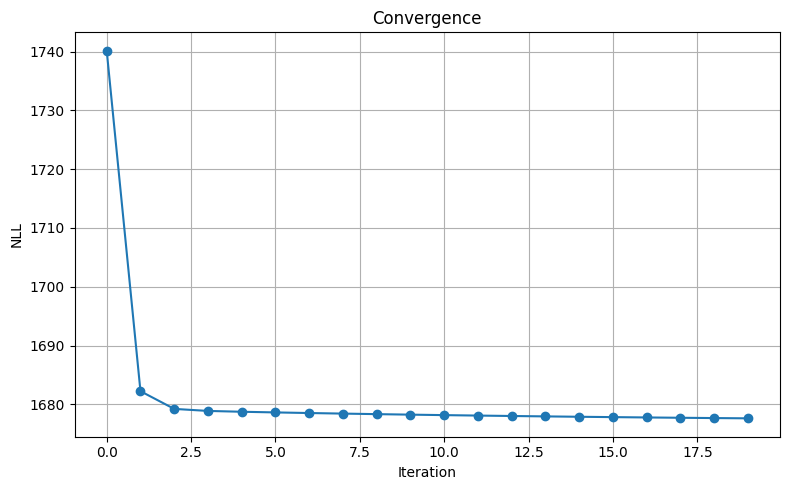

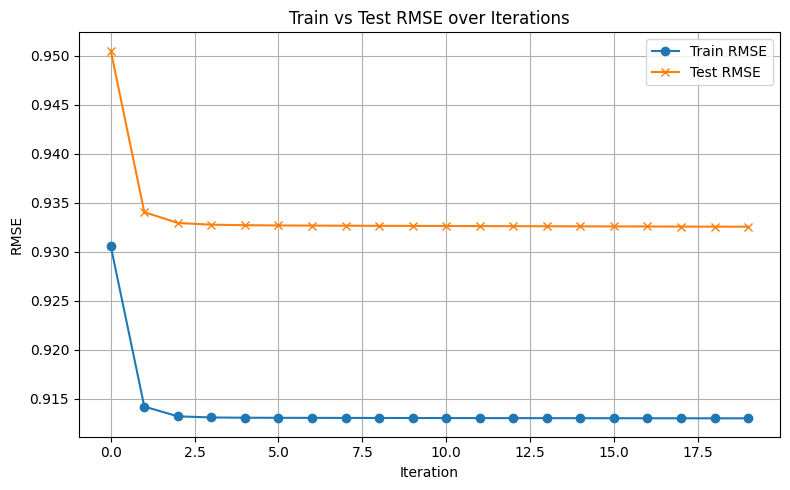

In [42]:
# Plot NLL convergence
plt.figure(figsize=(8, 5))
plt.plot(nll_history, marker='o')
plt.xlabel('Iteration')
plt.ylabel('NLL')
plt.title('Convergence')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Train vs Test RMSE
plt.figure(figsize=(8, 5))
plt.plot(train_rmse_history, label='Train RMSE', marker='o')
plt.plot(test_rmse_history, label='Test RMSE', marker='x')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.title('Train vs Test RMSE over Iterations')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Implement alternating least squares (bias + latent factors)

This model extends bias-only collaborative filtering to include latent user and item embeddings, capturing higher-order interaction structure beyond simple additive effects.

### Bias updates

$$
b_m^{(u)} = \frac{\lambda \sum_{n \in \Omega(m)} \left(r_{mn} - (\mathbf{u}_m^T \mathbf{v}_n + b_n^{(i)})\right)}{\lambda |\Omega(m)| + \gamma}
$$

$$
b_n^{(i)} = \frac{\lambda \sum_{m \in \Omega(n)} \left(r_{mn} - (\mathbf{u}_m^T \mathbf{v}_n + b_m^{(u)})\right)}{\lambda |\Omega(n)| + \gamma}
$$

### Latent factor updates

$$
\mathbf{u}_m =
\left(\lambda \sum_{n} \mathbf{v}_n \mathbf{v}_n^T + \tau \mathbf{I}\right)^{-1}
\left(\lambda \sum_{n} \mathbf{v}_n (r_{mn} - b_m^{(u)} - b_n^{(i)})\right)
$$

$$
\mathbf{v}_n =
\left(\lambda \sum_{m} \mathbf{u}_m \mathbf{u}_m^T + \tau \mathbf{I}\right)^{-1}
\left(\lambda \sum_{m} \mathbf{u}_m (r_{mn} - b_m^{(u)} - b_n^{(i)})\right)
$$

A full derivation of this optimisation procedure, together with extensions to latent embeddings and feature-based models, is provided in the file `derivations.md`.

In [43]:
# Hyperparameters
lam = 0.017684422019387584
gamma = 0.06224262766516858
tau = 0.29037492246228525
k = 15
max_iter = 25

# Initialize biases and embeddings
user_bias = np.zeros(n_users)
item_bias = np.zeros(n_items)
user_embedding = np.random.normal(scale=0.1, size=(n_users, k))
item_embedding = np.random.normal(scale=0.1, size=(n_items, k))

# History tracking
nll_history = []
train_rmse_history = []
test_rmse_history = []

for iteration in range(max_iter):
    # Update user biases and embeddings
    for user in range(1, n_users + 1):
        rated = user_ratings[user]
        bias_sum = 0
        n_rated = 0

        items = []
        ratings_list = []

        # Compute user bias
        for item, r in rated:
            items.append(item - 1)
            ratings_list.append(r)
            pred = user_embedding[user - 1].T @ item_embedding[item - 1] + item_bias[item - 1] + mu_train
            bias_sum += r - pred
            n_rated += 1
        user_bias[user - 1] = lam * bias_sum / (lam * n_rated + gamma)

        # Update user embedding
        sum1 = item_embedding[items].T @ item_embedding[items]
        sum2 = item_embedding[items].T @ (np.array(ratings_list) - user_bias[user - 1] - item_bias[items] - mu_train)
        p1 = lam * sum1 + tau * np.eye(k)
        p2 = lam * sum2
        user_embedding[user - 1] = np.linalg.solve(p1, p2)

    # Update item biases and embeddings
    for item in range(1, n_items + 1):
        rated = item_ratings[item]
        bias_sum = 0
        n_rated = 0

        users_list = []
        ratings_list = []

        # Compute item bias
        for user, r in rated:
            users_list.append(user - 1)
            ratings_list.append(r)
            pred = item_embedding[item - 1].T @ user_embedding[user - 1] + user_bias[user - 1] + mu_train
            bias_sum += r - pred
            n_rated += 1
        item_bias[item - 1] = lam * bias_sum / (lam * n_rated + gamma)

        # Update item embedding
        sum1 = user_embedding[users_list].T @ user_embedding[users_list]
        sum2 = user_embedding[users_list].T @ (np.array(ratings_list) - item_bias[item - 1] - user_bias[users_list] - mu_train)
        p1 = lam * sum1 + tau * np.eye(k)
        p2 = lam * sum2
        item_embedding[item - 1] = np.linalg.solve(p1, p2)

    # Compute negative log-likelihood
    squared_error = 0
    for user in range(1, n_users + 1):
        for item, r in user_ratings[user]:
            pred = user_embedding[user - 1].T @ item_embedding[item - 1] + user_bias[user - 1] + item_bias[item - 1] + mu_train
            squared_error += (r - pred) ** 2

    reg_user_bias = np.sum(user_bias ** 2)
    reg_item_bias = np.sum(item_bias ** 2)
    reg_user_embedding = np.sum(user_embedding ** 2)
    reg_item_embedding = np.sum(item_embedding ** 2)

    nll = (lam / 2) * squared_error + \
          (gamma / 2) * (reg_user_bias + reg_item_bias) + \
          (tau / 2) * (reg_user_embedding + reg_item_embedding)
    nll_history.append(nll)

    # Compute training RMSE
    train_sq_err = 0
    n_train = 0
    for user in range(1, n_users + 1):
        for item, r in user_ratings[user]:
            pred = user_embedding[user - 1].T @ item_embedding[item - 1] + user_bias[user - 1] + item_bias[item - 1] + mu_train
            train_sq_err += (r - pred) ** 2
            n_train += 1
    train_rmse = np.sqrt(train_sq_err / n_train)
    train_rmse_history.append(train_rmse)

    # Compute test RMSE
    test_sq_err = 0
    n_test = 0
    test_data = data_by_user_test.tocoo()
    for user, item, r in zip(test_data.row, test_data.col, test_data.data):
        pred = user_embedding[user].T @ item_embedding[item] + user_bias[user] + item_bias[item] + mu_train
        test_sq_err += (r - pred) ** 2
        n_test += 1
    test_rmse = np.sqrt(test_sq_err / n_test)
    test_rmse_history.append(test_rmse)

    # Print progress
    print(f"Iteration {iteration + 1}, "
          f"NLL = {nll:.4f}, "
          f"Train RMSE = {train_rmse:.4f}, "
          f"Test RMSE = {test_rmse:.4f}")

Iteration 1, NLL = 626.8162, Train RMSE = 0.9242, Test RMSE = 0.9485
Iteration 2, NLL = 598.3985, Train RMSE = 0.8908, Test RMSE = 0.9246
Iteration 3, NLL = 586.2892, Train RMSE = 0.8602, Test RMSE = 0.9127
Iteration 4, NLL = 581.6242, Train RMSE = 0.8424, Test RMSE = 0.9087
Iteration 5, NLL = 579.3954, Train RMSE = 0.8318, Test RMSE = 0.9069
Iteration 6, NLL = 578.1634, Train RMSE = 0.8252, Test RMSE = 0.9058
Iteration 7, NLL = 577.4262, Train RMSE = 0.8211, Test RMSE = 0.9051
Iteration 8, NLL = 576.9604, Train RMSE = 0.8185, Test RMSE = 0.9047
Iteration 9, NLL = 576.6492, Train RMSE = 0.8168, Test RMSE = 0.9045
Iteration 10, NLL = 576.4268, Train RMSE = 0.8157, Test RMSE = 0.9043
Iteration 11, NLL = 576.2583, Train RMSE = 0.8149, Test RMSE = 0.9042
Iteration 12, NLL = 576.1253, Train RMSE = 0.8144, Test RMSE = 0.9041
Iteration 13, NLL = 576.0177, Train RMSE = 0.8139, Test RMSE = 0.9041
Iteration 14, NLL = 575.9293, Train RMSE = 0.8136, Test RMSE = 0.9040
Iteration 15, NLL = 575.8558,

Adding latent embeddings further improves the test RMSE from $0,9326$ to $0,9036$.

### Convergence and generalisation analysis

This cell visualises the learning dynamics of the full latent factor model.

The first plot shows the evolution of the negative log-likelihood over iterations, indicating whether the alternating optimisation procedure is converging to a stable solution.

The second plot compares training and test RMSE across iterations, providing a view of generalisation performance and allowing assessment of overfitting as model complexity increases.

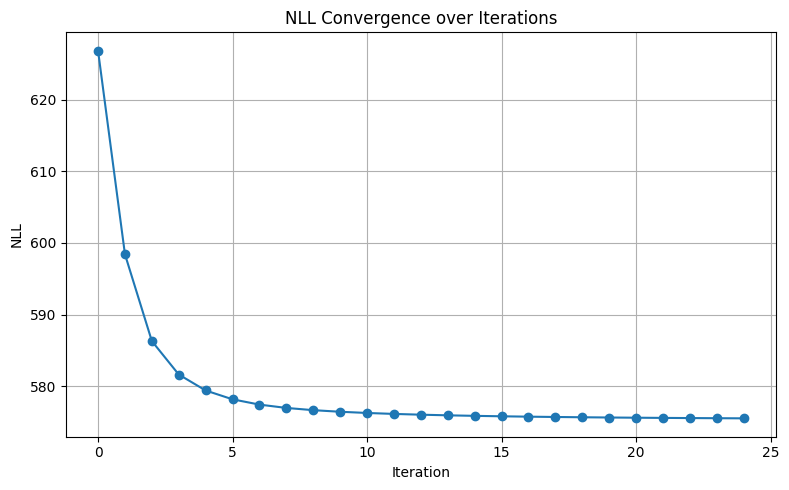

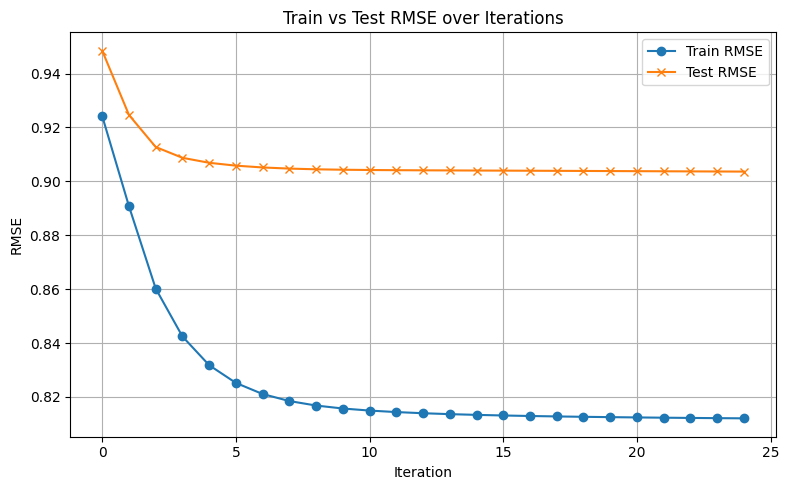

In [44]:
# Plot NLL convergence
plt.figure(figsize=(8, 5))
plt.plot(nll_history, marker='o')
plt.xlabel('Iteration')
plt.ylabel('NLL')
plt.title('NLL Convergence over Iterations')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Train vs Test RMSE
plt.figure(figsize=(8, 5))
plt.plot(train_rmse_history, label='Train RMSE', marker='o')
plt.plot(test_rmse_history, label='Test RMSE', marker='x')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.title('Train vs Test RMSE over Iterations')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
